# DRL Coursework 1: Q-Table Heatmap Analysis
Adds Q-table heatmaps to inspect the learned tabular policy by patient type.


## Imports
Libraries are grouped first so every later cell has the same dependencies available.


In [ ]:
import random
from collections import deque
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn as nn
import torch.optim as optim


## Reproducibility setup
A fixed seed makes random, NumPy, and PyTorch sampling easier to reproduce.


In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


## Environment definition
The hospital environment stores bed availability, patient type, actions, rewards, and transitions.


In [ ]:
class HospitalEnv:
    def __init__(self, icu_max=10, gen_max=30):
        self.icu_max = icu_max
        self.gen_max = gen_max
        self.reset()

    def reset(self):
        self.icu_free = np.random.randint(0, self.icu_max + 1)
        self.gen_free = np.random.randint(0, self.gen_max + 1)
        self.ptype = np.random.choice([0, 1, 2])
        return self._get_state()

    def _get_state(self):
        return (self.icu_free, self.gen_free, self.ptype)

    def step(self, action):
        reward = 0
        icu, gen, p = self.icu_free, self.gen_free, self.ptype

        # APPLY ACTION
        if action == 0:  # allocate ICU
            if icu > 0:
                self.icu_free -= 1
                reward += 5 if p in [0, 1] else -3
            else:
                reward -= 10

        elif action == 1:  # allocate general
            if gen > 0:
                self.gen_free -= 1
                if p == 2:
                    reward += 5
                elif p in [0, 1]:
                    reward += -3 if icu > 0 else 2
            else:
                reward -= 10

        elif action == 2:  # delay
            reward -= 1
            if p == 0:
                reward -= 10

        # DISCHARGES
        if random.random() < 0.3:
            self.icu_free = min(self.icu_free + 1, self.icu_max)
        if random.random() < 0.4:
            self.gen_free = min(self.gen_free + 1, self.gen_max)

        # NEW PATIENT ARRIVAL
        self.ptype = np.random.choice([0, 1, 2], p=[0.2, 0.3, 0.5])

        return self._get_state(), reward, False


## Supporting code
This code supports the surrounding experiment section.


In [ ]:
# 2. TABULAR Q-LEARNING

ICU_MAX = 3
GEN_MAX = 4
PTYPE_N = 3
N_STATES = (ICU_MAX + 1) * (GEN_MAX + 1) * PTYPE_N
N_ACTIONS = 3


## Tabular Q-learning
These helpers map states to Q-table rows and update values with epsilon-greedy exploration.


In [ ]:
def state_to_index(s):
    icu, gen, p = s
    return icu * ((GEN_MAX + 1) * PTYPE_N) + gen * PTYPE_N + p


## Tabular Q-learning
These helpers map states to Q-table rows and update values with epsilon-greedy exploration.


In [ ]:
def run_q_learning(episodes=1500, alpha=0.3, gamma=0.9, epsilon=0.2):
    env = HospitalEnv(ICU_MAX, GEN_MAX)
    Q = np.zeros((N_STATES, N_ACTIONS))
    rewards_per_episode = []

    for ep in range(episodes):
        s = env.reset()
        total_reward = 0

        for t in range(50):
            s_idx = state_to_index(s)

            # epsilon-greedy
            if random.random() < epsilon:
                a = np.random.randint(0, N_ACTIONS)
            else:
                a = np.argmax(Q[s_idx])

            s_next, r, done = env.step(a)
            s_next_idx = state_to_index(s_next)

            Q[s_idx, a] += alpha * (r + gamma * np.max(Q[s_next_idx]) - Q[s_idx, a])

            s = s_next
            total_reward += r

        rewards_per_episode.append(total_reward)

    return Q, rewards_per_episode


## Q-table heatmap
The heatmap visualises the best learned Q-values across bed states and patient types.


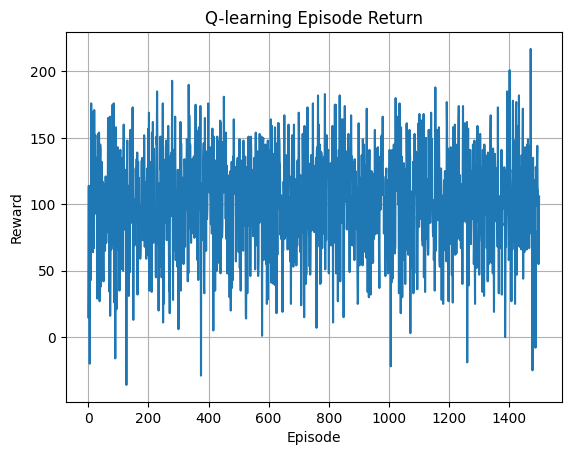

In [ ]:
def plot_q_heatmaps(Q):
    """
    Produces 3 heatmaps (one per patient type) showing max-Q values
    across ICU (0–10) and GEN (0–30).
    """
    for p in range(3):
        heatmap = np.zeros((ICU_MAX + 1, GEN_MAX + 1))

        for icu in range(ICU_MAX + 1):
            for gen in range(GEN_MAX + 1):
                idx = state_to_index((icu, gen, p))
                heatmap[icu, gen] = np.max(Q[idx])

        plt.figure(figsize=(12, 6))
        sns.heatmap(
            heatmap,
            cmap="viridis",
            xticklabels=5,
            yticklabels=1
        )
        plt.title(f"Max-Q Heatmap for Patient Type {p} (0=Emerg,1=Urgent,2=Elective)")
        plt.xlabel("General Beds Free")
        plt.ylabel("ICU Beds Free")
        plt.tight_layout()
        plt.show()


## Supporting code
This code supports the surrounding experiment section.


In [ ]:
# 4. DEEP RL (DQN / DOUBLE / DUELING)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


## State vector representation
Deep RL models use numeric state vectors instead of integer Q-table indices.


In [ ]:
def state_to_vector(s):
    icu, gen, p = s
    p_onehot = np.zeros(3, dtype=np.float32)
    p_onehot[p] = 1.0
    return np.array([icu, gen] + p_onehot.tolist(), dtype=np.float32)


## Replay buffer
Experience replay stores transitions so DQN updates can sample mixed past experience.


In [ ]:
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, s, a, r, s2, d):
        self.buffer.append((s, a, r, s2, d))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, s2, d = zip(*batch)
        return (
            torch.tensor(s, dtype=torch.float32, device=device),
            torch.tensor(a, dtype=torch.long, device=device),
            torch.tensor(r, dtype=torch.float32, device=device),
            torch.tensor(s2, dtype=torch.float32, device=device),
            torch.tensor(d, dtype=torch.float32, device=device),
        )

    def __len__(self):
        return len(self.buffer)


## DQN network models
Standard and dueling networks estimate action values for each state.


In [ ]:
class DQN(nn.Module):
    def __init__(self, state_dim=5, action_dim=3, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, action_dim)
        )

    def forward(self, x):
        return self.net(x)


## DQN network models
Standard and dueling networks estimate action values for each state.


In [ ]:
class DuelingDQN(nn.Module):
    def __init__(self, state_dim=5, action_dim=3, hidden=64):
        super().__init__()
        self.feature = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU()
        )
        self.value = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )
        self.adv = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, action_dim)
        )

    def forward(self, x):
        f = self.feature(x)
        v = self.value(f)
        a = self.adv(f)
        return v + a - a.mean(dim=1, keepdim=True)


## DQN training loop
The training loop supports standard DQN, Double DQN, and Dueling Double DQN.


In [ ]:
def train_dqn(
    episodes=1500,
    gamma=0.99,
    lr=1e-3,
    batch_size=64,
    buffer_capacity=10000,
    min_buffer_size=1000,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=500,
    target_update_freq=50,
    double_dqn=True,
    dueling=False
):
    env = HospitalEnv(ICU_MAX, GEN_MAX)

    if dueling:
        policy = DuelingDQN().to(device)
        target = DuelingDQN().to(device)
    else:
        policy = DQN().to(device)
        target = DQN().to(device)

    target.load_state_dict(policy.state_dict())
    target.eval()

    opt = optim.Adam(policy.parameters(), lr=lr)
    buffer = ReplayBuffer(buffer_capacity)

    rewards = []
    steps = 0

    for ep in range(episodes):
        s = env.reset()
        s_vec = state_to_vector(s)
        total = 0

        for t in range(50):
            epsilon = epsilon_end + (epsilon_start - epsilon_end) * np.exp(-steps / epsilon_decay)
            steps += 1

            if random.random() < epsilon:
                a = np.random.randint(0, 3)
            else:
                with torch.no_grad():
                    q = policy(torch.tensor([s_vec], device=device))
                    a = q.argmax().item()

            s2, r, d = env.step(a)
            s2_vec = state_to_vector(s2)

            buffer.push(s_vec, a, r, s2_vec, d)
            s_vec = s2_vec
            total += r

            if len(buffer) >= min_buffer_size:
                S, A, R, S2, D = buffer.sample(batch_size)

                q_vals = policy(S).gather(1, A.unsqueeze(1)).squeeze(1)

                with torch.no_grad():
                    if double_dqn:
                        next_actions = policy(S2).argmax(dim=1, keepdim=True)
                        next_q = target(S2).gather(1, next_actions).squeeze(1)
                    else:
                        next_q = target(S2).max(dim=1)[0]

                    targets = R + gamma * (1 - D) * next_q

                loss = nn.MSELoss()(q_vals, targets)
                opt.zero_grad()
                loss.backward()
                opt.step()

        rewards.append(total)

        if ep % target_update_freq == 0:
            target.load_state_dict(policy.state_dict())

    return rewards


## Q-learning experiment
This cell runs the tabular baseline and plots reward, rejection, or utilisation traces.


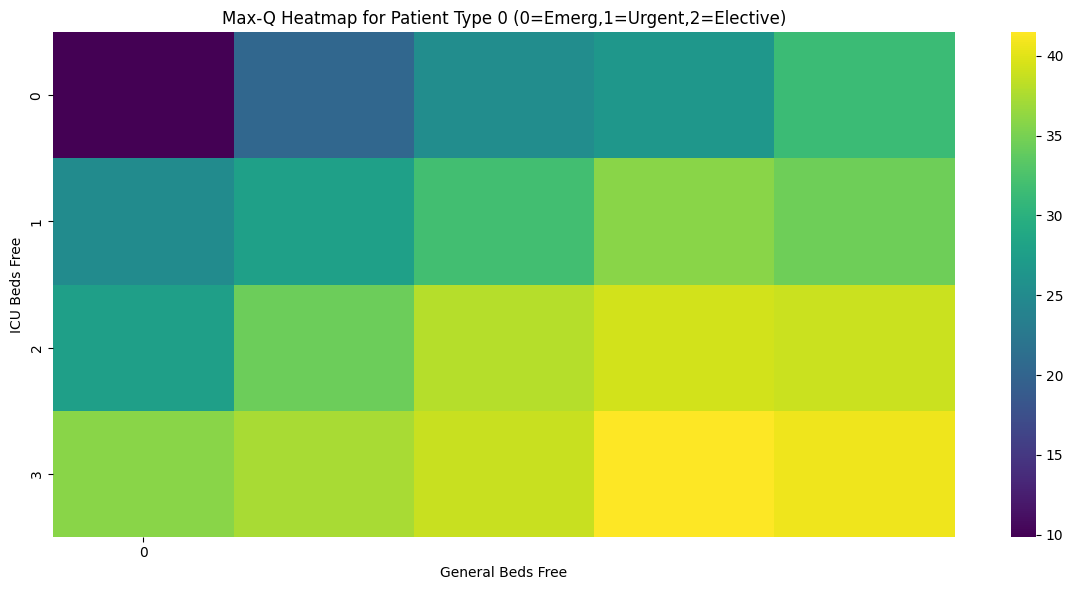

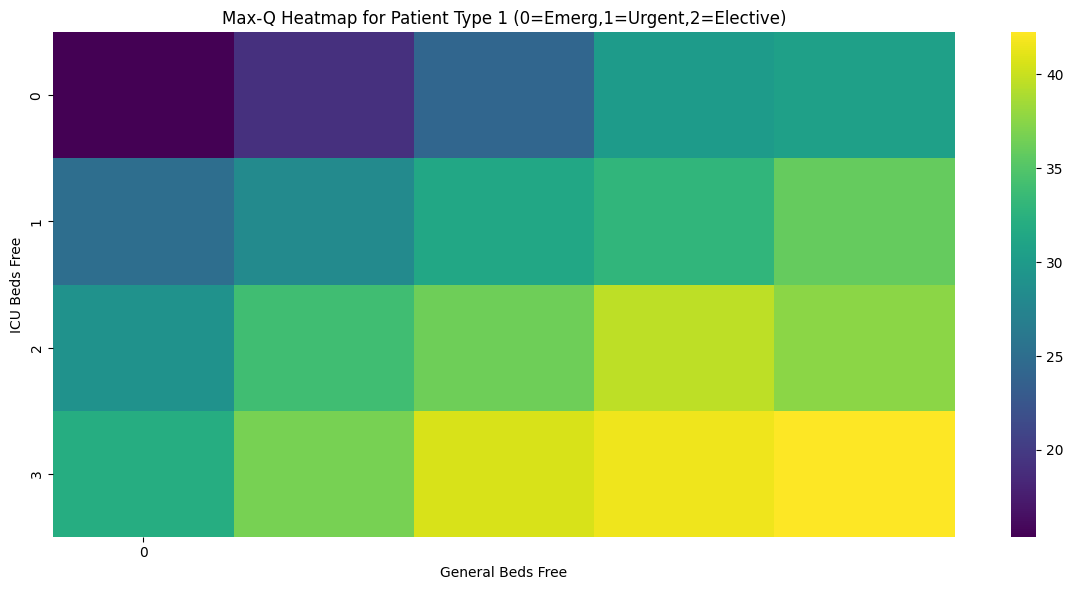

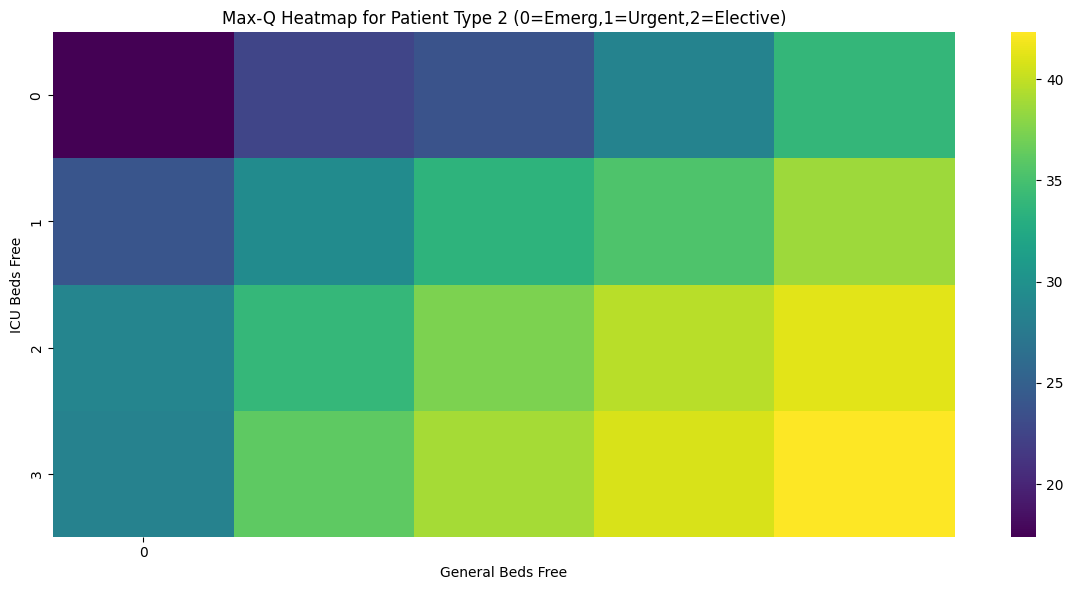

KeyboardInterrupt: 

In [ ]:
# 5. RUN EXPERIMENTS

if __name__ == "__main__":

    # Q-learning
    Q, rewards_q = run_q_learning()

    plt.plot(rewards_q)
    plt.title("Q-learning Episode Return")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.grid(True)
    plt.show()

    # Heatmaps
    plot_q_heatmaps(Q)

    # Deep RL
    rewards_dqn = train_dqn(double_dqn=False, dueling=False)
    rewards_double = train_dqn(double_dqn=True, dueling=False)
    rewards_dueling = train_dqn(double_dqn=True, dueling=True)

    plt.figure(figsize=(10, 5))
    plt.plot(rewards_dqn, label="DQN")
    plt.plot(rewards_double, label="Double DQN")
    plt.plot(rewards_dueling, label="Dueling Double DQN")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.title("Deep RL Algorithms (ICU=10, GEN=30)")
    plt.legend()
    plt.grid(True)
    plt.show()
